In [26]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

### Getting the data

In [27]:
df = pd.read_csv('data.csv')
df[:10]

,avg_reaction_time,reaction_time_std,memory_score,accuracy,stroop_error_rate,go_nogo_accuracy,risk_level
0,335.5,38.2,0.842,0.941,0.057,0.848,Low
1,300.0,44.5,0.885,0.789,0.063,0.835,Low
2,542.2,104.9,0.850,0.728,0.229,0.639,Low
3,356.0,44.5,0.843,0.842,0.039,0.870,Low
4,370.8,38.9,0.719,0.946,0.191,0.952,Low
5,793.1,182.0,0.329,0.409,0.446,0.442,High
6,334.8,36.3,0.867,0.933,0.116,0.925,Low
7,319.7,46.0,0.806,0.855,0.127,0.826,Low
8,717.7,158.1,0.468,0.576,0.490,0.504,High
9,556.1,88.5,0.492,0.773,0.283,0.682,Low


#### Veriying the data does side one type of label

In [28]:
low_count = len(df[df['risk_level'] == 'Low'])
moderate_count = len(df[df['risk_level'] == 'Moderate'])
high_count = len(df[df['risk_level'] == 'High'])

print(f'High: {high_count}\nModerate: {moderate_count}\nLow: {low_count}')
print(df['risk_level'].value_counts())

High: 145
Moderate: 208
Low: 647
risk_level
Low         647
Moderate    208
High        145
Name: count, dtype: int64


### Splitting the data into labels and features

In [29]:
X = df[['avg_reaction_time','reaction_time_std','memory_score','accuracy','stroop_error_rate','go_nogo_accuracy']].values
y = df['risk_level']
X.shape

(1000, 6)

### Setting the labels to 0 - 2 (integers)

In [30]:
label_map = {'Low': 0, 'Moderate': 1, 'High': 2}
y = y.map(label_map)

### Splitting the data into the 80% training and 20% testing format

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 )

### Creating the model

In [32]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

### Getting scores and report

Accuracy: 0.96
Classification Report:
              precision    recall  f1-score   support

         Low       0.97      0.99      0.98       135
    Moderate       0.93      0.81      0.87        32
        High       0.94      1.00      0.97        33

    accuracy                           0.96       200
   macro avg       0.95      0.93      0.94       200
weighted avg       0.96      0.96      0.96       200



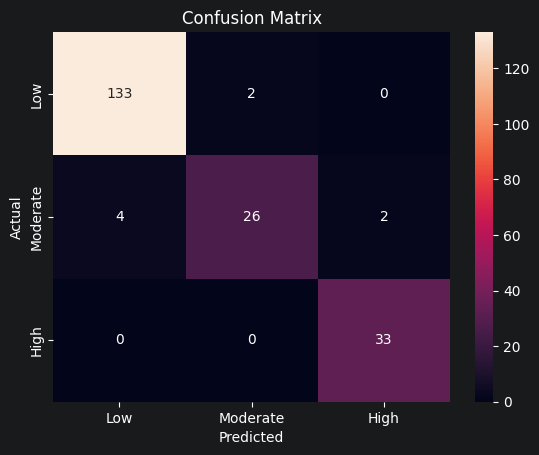

In [33]:
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, target_names=['Low', 'Moderate', 'High'])
print(f'Accuracy: {accuracy}\nClassification Report:\n{classification_rep}')
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Low', 'Moderate', 'High'],
            yticklabels=['Low', 'Moderate', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Exporting the model

In [34]:
joblib.dump(model, 'cognify_model.pkl')

['cognify_model.pkl']